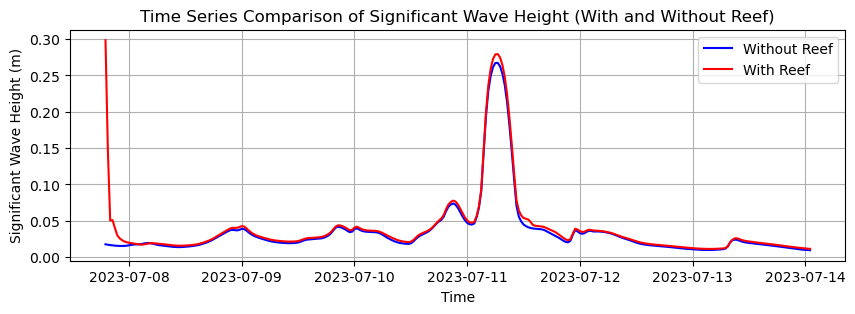

In [14]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# Load the first DFSU file
filename1 = r"D:\Phd Research\Wave Model\Simulation\Climate_Change_condition\Without_reef_scenarios\Wave_Model_Sep_1943_10_yr.sw - Result Files\wave_CC_10_yr.dfsu"
dfsu1 = mikeio.Dfsu(filename1)

# Load the second DFSU file
filename2 = r"D:\Phd Research\Wave Model\Simulation\Climate_Change_condition\With_reef_scenarios\Wave_Model_Sep_1943_10_yr_withreef_200m.sw - Result Files\wave_CC_10_yr_with_reef_200m.dfsu"
dfsu2 = mikeio.Dfsu(filename2)

# Provided coordinates
x_coord = 736261.87
y_coord = 3178681.36

# Get the element coordinates from both DFSU files
element_coords1 = np.array(dfsu1.element_coordinates)
element_coords2 = np.array(dfsu2.element_coordinates)

# Calculate distances from the provided coordinate to each element
distances1 = np.sqrt((element_coords1[:, 0] - x_coord)**2 + (element_coords1[:, 1] - y_coord)**2)
distances2 = np.sqrt((element_coords2[:, 0] - x_coord)**2 + (element_coords2[:, 1] - y_coord)**2)

# Find the index of the nearest element
nearest_element_index1 = np.argmin(distances1)
nearest_element_index2 = np.argmin(distances2)

# Define the item index for 'Significant Wave Height' or other parameter
item_index = 0  # Replace with the correct index for Significant Wave Height

# Extract time series data for the specified element from both files
dataset1 = dfsu1.read(items=[item_index])
dataset2 = dfsu2.read(items=[item_index])

# Extract time series for the selected element
timeseries1 = dataset1[0].to_numpy()[:, nearest_element_index1]
timeseries2 = dataset2[0].to_numpy()[:, nearest_element_index2]

# Extract the time data from both files
time1 = dataset1.time
time2 = dataset2.time

# Find overlapping time steps between the two files
matching_times = np.intersect1d(time1, time2)

# Filter the time series data for matching times
filtered_timeseries1 = timeseries1[np.isin(time1, matching_times)]
filtered_timeseries2 = timeseries2[np.isin(time2, matching_times)]

# Filter the time arrays for matching times
filtered_time = matching_times

# Plot the filtered time series data together
plt.figure(figsize=(10,3))
plt.plot(filtered_time, filtered_timeseries1, label='Without Reef', color='blue')
plt.plot(filtered_time, filtered_timeseries2, label='With Reef', color='red')

# Add labels and legend
plt.xlabel('Time')
plt.ylabel('Significant Wave Height (m)')  # Update the label if needed
plt.title('Time Series Comparison of Significant Wave Height (With and Without Reef)')
plt.legend()

# Show plot
plt.grid(True)
plt.show()
